# 목차

### 1. GAN에 대한 설명
#### 1.1. Generator
#### 1.2. Discriminator
#### 1.3. 손실함수와 훈련

### 2. 사전작업
#### 2.1. 모듈 불러오기
#### 2.2. 데이터 불러오기

### 3. CIFAR-10과 비슷한 이미지 생성하기
#### 3.1. Generator
#### 3.2. Discriminator
#### 3.3. 손실함수 설정
#### 3.4. 모델 학습
#### 3.5. 이미지 생성하기

### 4. 회고

# 1. GAN에 대한 설명

GAN(generative adversarial network)는 두 개의 함수 generator와 discriminator로 이루어져 있다.
genrator와 dicriminator가 서로 경쟁하면서 학습하고, 이를 통해 우수한 성능의 generator를 만들어내는 것이 GAN의 목적이다.
Ian Goodfellow가 처음 GAN의 구조를 고안한 이래로 Style GAN, cGAN, Wasserstein GAN 등 아주 많은 종류의 GAN들이 등장했지만, GAN을 유명하게 만든 것은 DCGAN이다.
여기에서, DC란, 'deep convolutional'의 의미로서, CNN 구조를 접목하여 만든 GAN이라는 의미이다.

DCGAN의 전체적인 구조는 다음과 같다.
(이 그림은, 여러 번 다시 불러올 것이다.)
지금 작성되어 있는 전체 코드에 맞춰서 이야기하겠다.

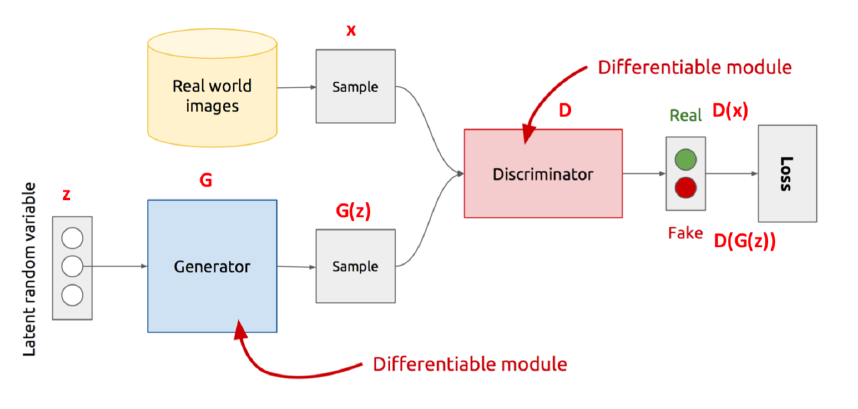

## 1.1. Generator

generator는, latent vector를 그림으로 만드는 함수로서 정의된다.
이때, latent vector는 100차원의 유클리드 벡터이고, 그림은 (32, 32, 3) 형태의 rank 3 tensor이다.
generator는 여러 층의 레이어로 구성되어 있다.

$$\text{generator}:\mathbb R^{100}\to\mathbb R^{32\times32\times3}$$

구체적인 설명은 generator의 코드 위에 적어보았다.

## 1.2. Discriminator

discriminator는, 그림이 입력되었을 때, 그 그림이 진짜인지 가짜인지를 판별해준다.
즉, binary classifier이고, (32, 32, 3) 형태의 텐서를 입력받아 0 혹은 1의 값을 출력한다.
0은, 해당 그림이 가짜라고 판별하는 것이고 1은 해당 그림이 진짜라고 판별하는 것이다.
하지만 조금 더 정확하게는, 0과 1 사이의 실수값을 출력한다.
다시 말해, 해당 그림이 진짜일 확률을 출력한다.

$$\text{discriminator}:\mathbb R^{32\times32\times3}\to[0,1]$$

discriminator가 0과 1 사이의 실수를 출력한다고, 방금 말했지만, 실제 코드 상에서는 0과 1 사이의 실수를 출력하는 것이 아닌, 일반적인 실수를 출력하는 것으로 되어 있다.
이것은 큰 문제가 되지 않는다. 마지막에 sigmoid를 넣거나, 아니면 cross entropy를 계산할 때 logit 옵션을 넣으면 되기 때문이다(`from_logits=True`).

## 1.3. 손실함수와 훈련

조금 더, 여기에 discriminator에 대해서 더 쓰고, GAN의 loss function에 대해서도 써보자.
generator는 $G$로, discriminator는 $D$라고 표기하자.
latent variable은 $z$로, 실제 이미지는 $x$라고 표기하자.
이때, GAN의 전체적인 구조는 다음과 같다.

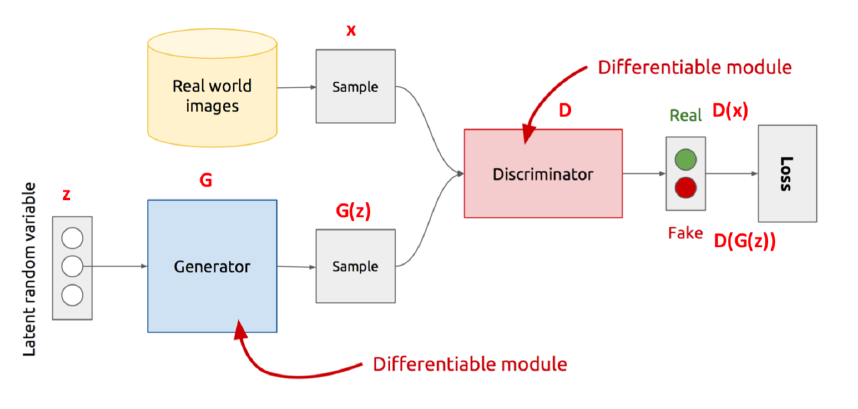

discriminator에 입력되는 그림(image)은 다음과 같은 두 종류이므로
- real image $x$
- generated image (fake image) $G(z)$  

GAN의 loss function은 $x$에 대한 항과 $z$에 대한 항 모두를 독립적으로 고려해야 한다.
구체적인 loss function은 다음과 같이 정의된다.

$$L(D,G)=\mathbb E_{x\sim\text{data}(x)}[\log D(x)]+\mathbb E_{z\sim p_g(z)}[\log(1-D(G(z)))]$$

여기에서, expectation $\mathbb E$의 의미는, 단순히 평균을 낸다는 뜻이다.
즉, 어떤 특별한 종류의 확률분포를 고려하는 것이 아니라, 그냥 uniform distribution을 생각할 때의 기댓값, 다시 말해, 산술평균을 낸다는 뜻이다.

이 loss function에 대한 task는
$$\min_G\max_D L(D,G)$$
이다.
즉, $G$의 입장에서는 $L$의 값이 줄어들었으면 좋겠고, D의 입장에서는 L의 값이 커졌으면 좋겠다는 것이다.
구체적으로는 다음과 같은 이유에서다.

$G$의 입장에서는, 자기가 만든 가짜 이미지 $G(z)$가 진짜처럼 판별되었으면 좋겠다.
즉, $D(G(z))$의 값이 최대한 크게, 1에 가깝게 출력되었으면 하는 입장이다.
그것은 $1-D(G(z))$의 값이 작아지는 방향이고, $\log(1-D(G(z)))$의 값이 작아지는 방향이며 $\mathbb E_z[\log(1-D(G(z)))]$가 작아지는 방향이다.
또한, $\mathbb E[\log D(x)]$는 $z$에 대한 함수가 아니므로, $\mathbb E[\log D(x)]$는 $z$의 입장에서는 상수이다.
다시 말해, 이것은 $L(D,G)$의 값이 작아지는 방향이라고 할 수 있다.

$D$의 입장에서는, 가짜 이미지 $G(z)$가 가짜처럼 판별되었으면 좋겠고, 진짜 이미지 $x$가 진짜처럼 판별되엇으면 좋겠다.
즉, $D(G(z))$의 값이 최대한 작게, 0에 가깝게 출력되었으면 좋겠고, $D(x)$의 값이 최대한 크게, 1에 가깝게 출력되었으면 좋겠다는 입장이다.
그것은 $1-D(G(z))$의 값이 커지는 방향이고, $\log(1-D(G(z)))$의 값이 커지는 방향이며 $\mathbb E_z[\log(1-D(G(z)))]$가 커지는 방향이다.
또한, $\log D(x)$의 값이 커지는 방향이고, $\mathbb E_x[\log D(x)]$의 값이 커지는 방향이다.
따라서 $L(D,G)$의 값이 커지는 방향이라고 할 수 있다.
(이때, 두 항을 단순히 더하여 loss function을 구성했다.
조금 더 정교하게 loss function을 구성하려면, 각 항에 적당한 weight을 주어야 할 것이다.)

따라서 GAN의 학습은 단순한 gradien descent가 아니다.
G의 입장에서는 gradient descent를 해야 하지만, D의 입장에서는 gradient ascent를 해야 한다.
정확하게는, 다음과 같은 순서를 따른다.

먼저 D에 대한 gradient ascent를 수행한다.
이때, D의 parameter들인 $\theta_D$만을 학습하고, $\theta_G$는 고정해놓는다.
D에 대한 학습이 완료되면, 이번에는 G에 대한 gradient descent를 수행한다.
이번에는 $\theta_G$만을 학습하고, $\theta_D$는 고정해놓는다.
이것이 끝나면 다시 D의 학습을 재개한다.

$$\text{D의 학습}\longrightarrow\text{G의 학습}\longrightarrow\text{D의 학습}\longrightarrow\text{G의 학습}\longrightarrow\cdots$$

조금 더 구체적으로는 G의 학습시에, loss function을 살짝 변형하여 학습하는 것이 학습효율을 더 높일 수 있고, G의 학습 한 번 당 D는 여러 번 학습을 하는 것이 일반적이다.
구체적인 알고리즘은 다음과 같다.
([DCGAN 논문](https://arxiv.org/abs/1511.06434v2)이 아닌 [GAN 논문](https://arxiv.org/abs/1511.06434v2)에서 가져왔다.
그러니까, DCGAN을 사용하는 지금 코드에는 살짝 안맞을 수도 있을 것 같다.)

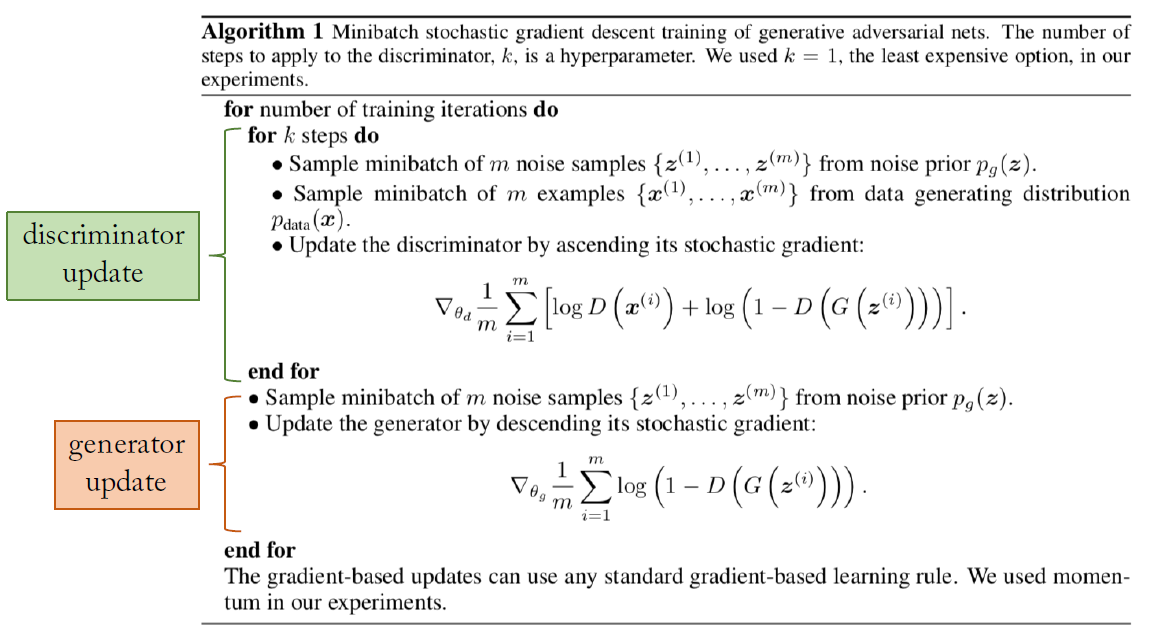

# 2. 사전작업

## 2.1. 모듈 불러오기

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pylab import rcParams

import os, glob, time, PIL, imageio

import tensorflow as tf
from tensorflow.keras import layers
from IPython import display

## 2.2. 데이터 불러오기

- 데이터는 `tf.keras.datasets.cifar10.load_data()`로 불러온다.
- `cifar10`의 label은 열 개이고 다음과 같다.
|0|1|2|3|4|5|6|7|8|9|
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
|airplane  |automobile|bird|cat|deer|dog|frog|horse|ship|truck|

In [2]:
(train_x, train_y), (test_x, test_y) = tf.keras.datasets.cifar10.load_data()

print(type(train_x))
print(type(test_x))
print(train_x.shape)
print(test_x.shape)
print(type(train_y))
print(type(test_y))
print(train_y.shape)
print(test_y.shape)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(50000, 32, 32, 3)
(10000, 32, 32, 3)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(50000, 1)
(10000, 1)


- unsupervised learning이기 때문에, `train_x`, `test_x`만 필요하고, `train_y`, `test_y`는 필요하지 않지만, 생김새를 확인하기 위해 `train_y`, `test_y`도 불러보았다.
- train_x를 -1과 1 사이의 값으로 고정시킨다. [1번 자료](https://github.com/soumith/ganhacks)의 1번 항목이 적용되었다.
- 하지만, 그림을 `imshow`로 표시하는 데 있어서는 -1과 1 사이의 값이 나와서는 안된다.
`imshow`의 인자로 들어가는 rank 3 tensor의 각각의 성분들은 0과 255 사이의 값을 가지거나, 아니면 0과 1 사이의 값을 가져야 한다.
여기에서는 `train_x[random_index]`의 성분들을  0과 1사이의 값으로 두었다.
구체적으로 설명하면, $f(x)=\frac{x-127.5}{127.5}$이고, $g(t)=\frac{t+1}2$일 때,
$$[0,255]\stackrel f\to[-1,1]\stackrel g\to[0,1]$$
이다.
`imshow`시 이 변환($g$)을 하지 않으면, 이미지의 각 성분들이 clipping된다는 오류가 뜨고, 그림 또한 검은 색에 가깝게 나온다.
이것은 픽셀값들이 $[-1,1]$에 분포되어 있는데, 그것을 $[0,1]$로 인식하려다보니, 절반에 해당하는 픽셀값들이 0으로 인식(clip)되고, 따라서 검은 색으로 나오는 것이다.

In [3]:
train_x = train_x.astype('float32')
train_x = (train_x - 127.5)/127.5

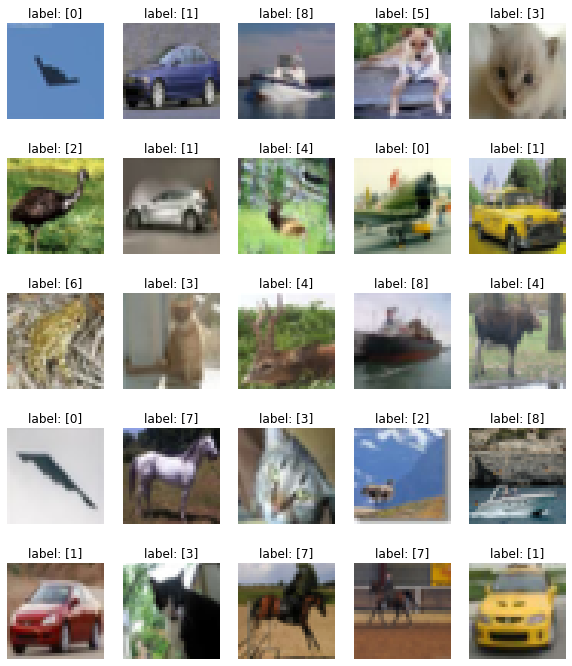

In [4]:
plt.figure(figsize=(10, 12))

for i in range(25):
    plt.subplot(5, 5, i+1)
    random_index = np.random.randint(1, 50000)
    plt.imshow((train_x[random_index]+1)/2.0)
    plt.title(f'label: {train_y[random_index]}')
    plt.axis('off')

plt.show()

In [5]:
BUFFER_SIZE = 60000
BATCH_SIZE = 256

- `tf.data.Dataset.from_tensor_slices(train_x).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)`을 통해 `train_x`를 텐서화한다.
 - `tf.data.Dataset.from_tensor_slices(train_x)`는 `train_x`의 데이터타입을 `np_array`에서 `tf_tensor`로 바꾸기 위함인 것 같다.
 - 하지만, 정확한 데이터타입명이 `tf_tensor`은 아니고 `tensorflow.python.data.ops.dataset_ops.TensorSliceDataset`와 같은 것으로 뜨는데, 이것이 정확히 어떤 것인지는 모르겠다.
 - 위 명령에서 `tf.data.Dataset.from_tensor_slices(train_x)`까지 선언한 객체는 (50000, 32, 32, 3)의 형태를 지닌 것으로 관찰된다. 50000는 사진의 갯수, 32와 32는 가로와 세로의 픽셀 사이즈, 3은 RGB channel을 나타낸다.
 - `.shuffle(BUFFER_SIZE)`은 단순히 사진의 순서를 바꾼 것으로 생각된다. 그러니까, 여전히 형태는 (50000, 32, 32, 3)이다.
 - `.batch(BATCH_SIZE)`는 데이터를 배치 형태로 설정한다. length가 (196,)인 것으로 출력되는데, `BUFFER_SIZE//BATCH_SIZE`의 값인 234와 달라서 어찌 된 일인지 모르겠다.

In [6]:
train_dataset = tf.data.Dataset.from_tensor_slices(train_x).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

In [7]:
# array = np.array([data for data in tf.data.Dataset.from_tensor_slices(train_x)])
# print(type(tf.data.Dataset.from_tensor_slices(train_x)),array.shape)
# array = np.array([data for data in tf.data.Dataset.from_tensor_slices(train_x).shuffle(BUFFER_SIZE)])
# print(type(tf.data.Dataset.from_tensor_slices(train_x).shuffle(BUFFER_SIZE)),array.shape)
# array = np.array([data for data in tf.data.Dataset.from_tensor_slices(train_x).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)])
# print(type(tf.data.Dataset.from_tensor_slices(train_x).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)),array.shape)
# print(BUFFER_SIZE//BATCH_SIZE)

# 3. CIFAR-10과 비슷한 이미지 생성하기

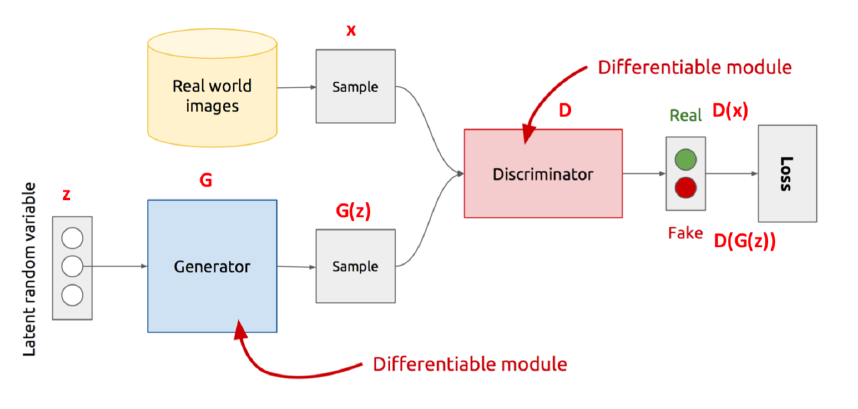

## 3.1. Generator

generator를 만드는 함수를 정의한다.
generator를 explicit하게 정의할 수도 있었을 것 같은데, 그렇게 하지 않고 generator를 만드는 함수를 정의하고 있다.

generator는, latent vector를 그림으로 만드는 함수로서 정의된다.
이때, latent vector는 100차원의 유클리드 벡터이고, 그림은 (32, 32, 3) 형태의 rank 3 tensor이다.
generator는 여러 층의 레이어로 구성되어 있다.

$$\text{generator}:\mathbb R^{100}\to\mathbb R^{32\times32\times3}$$

첫번째 레이어는 100차원의 latent vector를 4096차원의 벡터로 바꾸는 fully connected layer로 구성되어 있다.
여기에 batch normalization을 적용하고, 활성화함수는 LeakyReLU를 설정한다.
이때, 4096차원의 벡터는, 곧바로 (2,2,1024) 형태의 rank 3 tensor로 변환된다.
단순히 `reshape` 명령을 통하여 그렇게 된다.
즉, 가로 세로가 2이고, channel의 개수가 1024인 rank 3 tensor가 출력되었다.

두번째 레이어부터 다섯번째 레이어까지는 upsampling을 통해 가로 세로의 길이를 늘리고, channel의 개수를 낮춰서 결국 우리가 원하는 (32, 32, 3) 형태의 rank 3 tensor가 출력되도록 한다.
그 과정에서 `Conv2DTranspose`가 사용되는데, 이것은 fractionally-strided convolution과 같은 것인듯 하다.
각 레이어의 출력에서 가로, 세로의 길이와 channel의 개수는 다음과 같다.

|입/출력|가로의 길이|세로의 길이|channel의 개수|벡터의 차원|
|:-:|:-:|:-:|:-:|:-:|
|첫번째 레이어의 입력| | |    |100|
|첫번째 레이어의 출력|2|2|1024||
|두번째 레이어의 출력|4|4|256||
|세번째 레이어의 출력|8|8|128||
|네번째 레이어의 출력|16|16|64||
|다섯번째 레이어의 출력|32|32|3||
latent vector는 `noise`라는 객체로서 정의된다.

시험삼아, 100차원 벡터(행벡터, 1$\times$100 matrix, `tf_tensor`)인 `noise` $z_0$를 generator에 넣으면 `generated_image`라는 이름의 객체가 생성된다.
이것을 수식으로는 $G(z_0)$로 표현할 수 있겠다.
이 객체 역시도 `tf_tensor`의 데이터타입으로 확인되며, shape은 (1, 32, 32, 3)로서 출력된다.

generator를 구성함에 있어, batch normalization을 사용한 것은 [1번자료](https://github.com/soumith/ganhacks)의 4번째 항목과 일치하지만, 거기에서 말하는 것처럼 "Construct different mini-batches for real and fake, i.e. each mini-batch needs to contain only all real images or all generated images."로 하지는 못했다. (이후 보완 필요)

또한, LeakyReLU를 사용한 것과 ConvTranspose2d를 사용한 것은 [1번자료](https://github.com/soumith/ganhacks)의 5번 항목과 일치한다.
하지만 pixelshuffle은 사용하지 않았다. (이후 보완 필요)
마지막 레이어에 `tanh`를 사용한 것은 [1번자료](https://github.com/soumith/ganhacks)의 1번 항목과 일치한다.

In [8]:
def make_generator_model():
    model = tf.keras.Sequential()

    model.add(layers.Dense(2*2*1024, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((2, 2, 1024)))

    model.add(layers.Conv2DTranspose(256, kernel_size=(5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(128, kernel_size=(5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    
    model.add(layers.Conv2DTranspose(64, kernel_size=(5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    
    model.add(layers.Conv2DTranspose(3, kernel_size=(5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))

    return model

In [9]:
generator = make_generator_model()
generator.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 4096)              409600    
_________________________________________________________________
batch_normalization (BatchNo (None, 4096)              16384     
_________________________________________________________________
leaky_re_lu (LeakyReLU)      (None, 4096)              0         
_________________________________________________________________
reshape (Reshape)            (None, 2, 2, 1024)        0         
_________________________________________________________________
conv2d_transpose (Conv2DTran (None, 4, 4, 256)         6553600   
_________________________________________________________________
batch_normalization_1 (Batch (None, 4, 4, 256)         1024      
_________________________________________________________________
leaky_re_lu_1 (LeakyReLU)    (None, 4, 4, 256)         0

In [10]:
noise = tf.random.normal([1, 100])
print(type(noise), noise.shape)

<class 'tensorflow.python.framework.ops.EagerTensor'> (1, 100)


In [11]:
generated_image = generator(noise, training=False)
print(type(generated_image),generated_image.shape)

<class 'tensorflow.python.framework.ops.EagerTensor'> (1, 32, 32, 3)


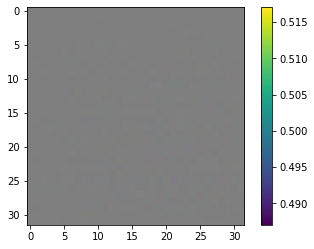

In [12]:
plt.imshow((generated_image[0]+1)/2.0)
plt.colorbar()
plt.show()

## 3.2. Discriminator

이번에는 discriminator를 만드는 함수를 정의한다.

discriminator는, 그림이 입력되었을 때, 그 그림이 진짜인지 가짜인지를 판별해준다.
즉, binary classifier이고, (32, 32, 3) 형태의 텐서를 입력받아 0 혹은 1의 값을 출력한다.
0은, 해당 그림이 가짜라고 판별하는 것이고 1은 해당 그림이 진짜라고 판별하는 것이다.
하지만 조금 더 정확하게는, 0과 1 사이의 실수값을 출력한다.
다시 말해, 해당 그림이 진짜일 확률을 출력한다.

$$\text{discriminator}:\mathbb R^{32\times32\times3}\to[0,1]$$

discriminator는 비교적 단순한 모델이다.
그냥 일반적인 CNN 모델이다.
총 세 개의 convolutional layer로 구성되어 있는데, 각각의 convolutional layer는 다음과 같이 구성되어 있다.
- `model.add(layers.Conv2D(64, (5, 5),  strides=(2, 2), padding='same', input_shape=[32, 32, 3]))`
- `model.add(layers.LeakyReLU())`
- `model.add(layers.Dropout(0.3))`

위에 적은 것은 첫번째 convolutional layer인데, channel 개수인 `64`만 제외하고는 두 번째와 세 번째 convolutional layer의 구조는 동일하다.
즉, stride (2,2)를 통해 downsampling을 진행한다. (MaxPooling을 수행하지 않는다.)
활성화함수로는 `LeakyReLU`를 사용하고 dropout layer 또한 넣어놓았다.

|입/출력|가로의 길이|세로의 길이|channel의 개수|벡터의 차원|
|:-:|:-:|:-:|:-:|:-:|
|첫번째 레이어의 입력|32|32|3||
|첫번째 레이어의 출력|16|16|64||
|두번째 레이어의 출력|8|8|128||
|세번째 레이어의 출력|4|4|256||
|네번째 레이어의 출력| | |   |4096|
|다섯번째 레이어의 출력| | | |1|

아까 시험삼아 만들어놓은 `noise` $z_0$를 generator에 입력해 얻은 `generated_image` $G(z_0)$를 discrimator에 넣어서 `decision`이라는 이름의 객체 $D(G(z_0))$를 생성했다.
이 객체는 `tf_tensor`의 데이터타입으로 확인되며, shape은 (1, 1)로서 출력된다.

[1번 자료](https://github.com/soumith/ganhacks)의 5번 항목에 따르면 downsampling 시에 (generator의 학습 시에) Average Pooling 혹은 Conv2d + stride를 사용하라고 되어 있다.
현재 코드에서는 후자(Conv2d + stride)를 선택한 셈이다.

[3번자료](https://machinelearningmastery.com/how-to-train-stable-generative-adversarial-networks/)에 따르면 Adam을 사용할 때, `beta_1`에 해당하는 값을 0.5로 바꾸는 것이 효과적이라고 되어 있다.
또한, 위의 GAN 논문에서 보듯이 generator를 한 번 학습할 때마다 discrimator를 $k$번 학습해야 한다.
이것은 [2번 자료](https://towardsdatascience.com/10-lessons-i-learned-training-generative-adversarial-networks-gans-for-a-year-c9071159628)의 5번 항목에 따르면 generator의 learning rate를 discriminator의 learning rate보다 몇 배 정도 크게 하여 학습하라는 말과 일치하는 것이라고 보았다. 따라서 generator의 learning rate을 discriminator의 learning rate보다 다섯 배 정도 크게 하여 학습을 진행했다.

In [13]:
def make_discriminator_model():
    model = tf.keras.Sequential()

    model.add(layers.Conv2D(64, (5, 5),  strides=(2, 2), padding='same', input_shape=[32, 32, 3]))
    model.add(layers.BatchNormalization())    
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.BatchNormalization())    
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))
    
    model.add(layers.Conv2D(256, (4, 4), strides=(2, 2), padding='same'))
    model.add(layers.BatchNormalization())    
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())

    model.add(layers.Dense(1))

    return model

In [14]:
discriminator = make_discriminator_model()
discriminator.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 16, 16, 64)        4864      
_________________________________________________________________
batch_normalization_4 (Batch (None, 16, 16, 64)        256       
_________________________________________________________________
leaky_re_lu_4 (LeakyReLU)    (None, 16, 16, 64)        0         
_________________________________________________________________
dropout (Dropout)            (None, 16, 16, 64)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 8, 8, 128)         204928    
_________________________________________________________________
batch_normalization_5 (Batch (None, 8, 8, 128)         512       
_________________________________________________________________
leaky_re_lu_5 (LeakyReLU)    (None, 8, 8, 128)        

In [15]:
decision = discriminator(generated_image, training=False)
print(type(decision), decision.shape,decision)

<class 'tensorflow.python.framework.ops.EagerTensor'> (1, 1) tf.Tensor([[0.00094321]], shape=(1, 1), dtype=float32)


## 3.3. 손실함수 설정

아까 손실함수를
$$L(D,G)=\mathbb E_{x\sim\text{data}(x)}[\log D(x)]+\mathbb E_{z\sim p_g(z)}[\log(1-D(G(z)))]$$
와 같이 정의하였다.
아래 코드를 보면, L(D,G)의 왼쪽 항이 `discriminator_loss`를 의미하고, 오른쪽 항이 `generator_loss`를 의미함을 알 수 있다.

binary cross entropy의 정의인
$$\text{BCE}(y,\hat y) = -\frac{1}{N} \sum_{i=1}^N y_i \log\big(\hat y_i\big) + (1-y_i) \log\big(1- \hat y_i\big).$$
를 통해서 보면, 정말로 `generator_loss`가 위의 식의 오른쪽항과 일치함을 알 수 있다.

`cross_entropy`의 첫번째 인자로서 `tf.ones_like(fake_output)`를 넣고 있는데, 이것은 모든 entry가 1인 tensor를 생각한다는 뜻이다.
즉, 위의 식에서, 모든 $i$에 대하여 $x_i=0$가 만족된다는 뜻이다.

In [16]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True, label_smoothing=0.1)

In [17]:
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

In [18]:
# print(tf.ones_like(generated_image))
# print(generated_image)
print(tf.ones_like(generated_image).shape)
print(generated_image.shape)

(1, 32, 32, 3)
(1, 32, 32, 3)


In [19]:
generator_loss(generated_image)

<tf.Tensor: shape=(), dtype=float32, numpy=0.6931418>

In [20]:
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

In [21]:
def discriminator_accuracy(real_output, fake_output):
    real_accuracy = tf.reduce_mean(tf.cast(tf.math.greater_equal(real_output, tf.constant([0.5])), tf.float32))
    fake_accuracy = tf.reduce_mean(tf.cast(tf.math.less(fake_output, tf.constant([0.5])), tf.float32))
    return real_accuracy, fake_accuracy

In [22]:
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=10e-4, beta_1=0.5)

## 3.4. 모델 훈련

In [23]:
noise_dim = 100
num_examples_to_generate = 16

seed = tf.random.normal([num_examples_to_generate, noise_dim])
seed.shape

TensorShape([16, 100])

In [24]:
@tf.function
def train_step(images):  #(1) 입력데이터
    noise = tf.random.normal([BATCH_SIZE, noise_dim])  #(2) 생성자 입력 노이즈

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:  #(3) tf.GradientTape() 오픈
        generated_images = generator(noise, training=True)  #(4) generated_images 생성

        #(5) discriminator 판별
        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        #(6) loss 계산
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

        #(7) accuracy 계산
        real_accuracy, fake_accuracy = discriminator_accuracy(real_output, fake_output) 
    
    #(8) gradient 계산
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    #(9) 모델 학습
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss, real_accuracy, fake_accuracy  #(10) 리턴값

In [25]:
def generate_and_save_images(model, epoch, it, sample_seeds):

    predictions = model(sample_seeds, training=False)

    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow((predictions[i]+1)/2.0)
        plt.axis('off')

    plt.savefig('{}/aiffel/dcgan_newimage/cifar10/generated_samples/sample_epoch_{:04d}_iter_{:03d}.png'
                    .format(os.getenv('HOME'), epoch, it))

    plt.show()

In [26]:
rcParams['figure.figsize'] = 15, 6    # matlab 차트의 기본 크기를 15,6으로 지정해 줍니다.

def draw_train_history(history, epoch):
    # summarize history for loss  
    plt.subplot(211)  
    plt.plot(history['gen_loss'])  
    plt.plot(history['disc_loss'])  
    plt.title('model loss')  
    plt.ylabel('loss')  
    plt.xlabel('batch iters')  
    plt.legend(['gen_loss', 'disc_loss'], loc='upper left')  

    # summarize history for accuracy  
    plt.subplot(212)  
    plt.plot(history['fake_accuracy'])  
    plt.plot(history['real_accuracy'])  
    plt.title('discriminator accuracy')  
    plt.ylabel('accuracy')  
    plt.xlabel('batch iters')  
    plt.legend(['fake_accuracy', 'real_accuracy'], loc='upper left')  
    
    # training_history 디렉토리에 epoch별로 그래프를 이미지 파일로 저장합니다.
    plt.savefig('{}/aiffel/dcgan_newimage/cifar10/training_history/train_history_{:04d}.png'
                    .format(os.getenv('HOME'), epoch))
    plt.show()

In [27]:
checkpoint_dir = os.getenv('HOME')+'/aiffel/dcgan_newimage/cifar10/training_checkpoints'

checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

In [28]:
def train(dataset, epochs, save_every):
    start = time.time()
    history = {'gen_loss':[], 'disc_loss':[], 'real_accuracy':[], 'fake_accuracy':[]}

    for epoch in range(epochs):
        epoch_start = time.time()
        for it, image_batch in enumerate(dataset):
            gen_loss, disc_loss, real_accuracy, fake_accuracy = train_step(image_batch)
            history['gen_loss'].append(gen_loss)
            history['disc_loss'].append(disc_loss)
            history['real_accuracy'].append(real_accuracy)
            history['fake_accuracy'].append(fake_accuracy)

            if it % 50 == 0:
                display.clear_output(wait=True)
                generate_and_save_images(generator, epoch+1, it+1, seed)
                print('Epoch {} | iter {}'.format(epoch+1, it+1))
                print('Time for epoch {} : {} sec'.format(epoch+1, int(time.time()-epoch_start)))

        if (epoch + 1) % save_every == 0:
            checkpoint.save(file_prefix=checkpoint_prefix)

        display.clear_output(wait=True)
        generate_and_save_images(generator, epochs, it, seed)
        print('Time for training : {} sec'.format(int(time.time()-start)))

        draw_train_history(history, epoch)

In [29]:
save_every = 5
EPOCHS = 50
import time
start_time = time.time()

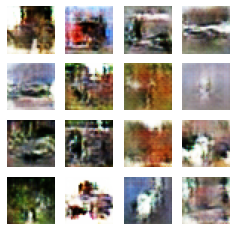

Time for training : 1434 sec


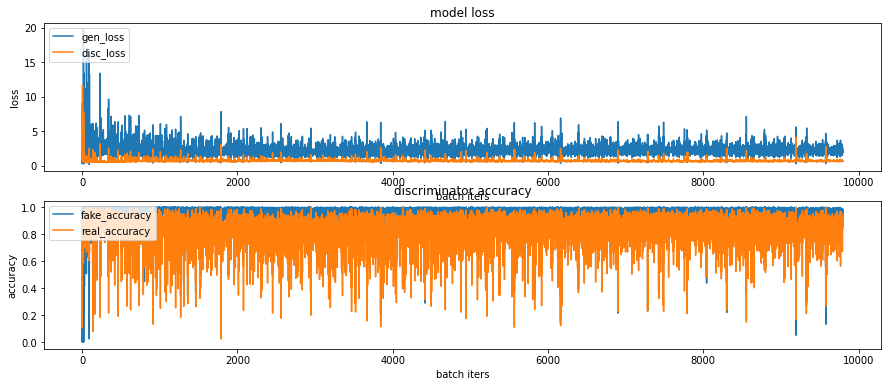

CPU times: user 24min 11s, sys: 1min 3s, total: 25min 15s
Wall time: 23min 55s


In [30]:
%%time
train(train_dataset, EPOCHS, save_every)

In [31]:
print("소요시간 :",time.time()-start_time,"초")

소요시간 : 1435.0876157283783 초


In [32]:
anim_file = os.getenv('HOME')+'/aiffel/dcgan_newimage/cifar10/cifar10_dcgan.gif'

with imageio.get_writer(anim_file, mode='I') as writer:
    filenames = glob.glob('{}/aiffel/dcgan_newimage/cifar10/generated_samples/sample*.png'.format(os.getenv('HOME')))
    filenames = sorted(filenames)
    last = -1
    for i, filename in enumerate(filenames):
        frame = 2*(i**0.5)
        if round(frame) > round(last):
            last = frame
        else:
            continue
        image = imageio.imread(filename)
        writer.append_data(image)
    image = imageio.imread(filename)
    writer.append_data(image)

!ls -l ~/aiffel/dcgan_newimage/fashion/fashion_mnist_dcgan.gif


-rw-r--r-- 1 root root 1078070 Oct 21 02:37 /aiffel/aiffel/dcgan_newimage/fashion/fashion_mnist_dcgan.gif


## 3.5. 이미지 생성

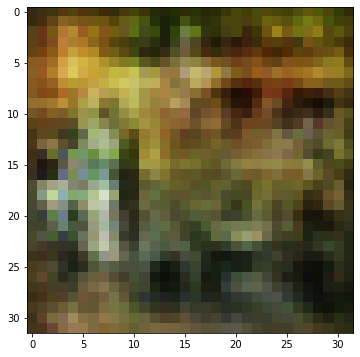

In [33]:
checkpoint_dir = os.getenv('HOME')+'/aiffel/dcgan_newi mage/cifar10/training_checkpoints'

latest = tf.train.latest_checkpoint(checkpoint_dir)
checkpoint.restore(latest)

generator = checkpoint.generator
discriminator = checkpoint.discriminator

# 로드한 모델이 정상적으로 이미지를 생성하는지 확인해 봅니다. 
noise = tf.random.normal([1, 100])
generated_image = generator(noise, training=False)
# np_generated = generated_image.numpy()
# np_generated = (np_generated * 127.5) + 127.5   # reverse of normalization
# np_generated = np_generated.astype(int)
plt.imshow((generated_image[0]+1)/2.0)
plt.show()  # 정상적으로 모델이 로드되었다면 랜덤 이미지가 아니라 CIFAR-10 이미지가 그려질 것입니다.


# 4. 회고

1. 처음으로 완성시켜본 GAN 코드였습니다.
사실 GAN의 개념은 이전부터 알고 있었고, 여러 번 배워놓았습니다.
또한 Wasserstein GAN을 구현해보려고 시도해본 적도 있습니다(만 실패했었습니다.)  
이번에, GAN 중에 가장 기본적인 모델로 알려져 있고, 가장 유명한 GAN인 DCGAN을 실습하게 되었지만, 뚜렷이 좋은 성과를 내지 못한 채로 exploration을 제출하게 되었습니다.  
2. 그래도 한 가지 의미있다고 생각드는 점은, GAN의 원리에 대해 다시 복습하고, 이것들을 제 언어로 다시 풀어 써서 정리해보았다는 것입니다. 이것이 루브릭 조건에 해당하지는 않지만, 두고두고 제가 GAN에 대한 자료가 필요할 때 때때로 찾아볼 수 있을 것 같습니다.  
3. 또 한가지 재미있었던 점은, GAN을 제대로 학습시키도록 하는 여러 조건들을 적용시켜보았다는 점입니다.
물론, 가시적인 성과가 전혀 나오지 않았고, 한 번 학습하는 데에도 시간이 많이 걸려서 여러 실험을 해볼 수 없었습니다.
다시 한 번, 빠르게 취업하여 개인 GPU를 사용할 수 있도록 돈을 모아야겠다는 생각을 했습니다.  
GAN의 학습은 기본적으로 saddle point에 해당하는, nash equilibrium을 찾아가는 과정이라고 알고 있습니다.
학습을 성공시키는 것이 악명이 높을 정도로 어렵다고도 알고 있습니다.
지금까지 살면서 두 번? 아니 세 번 정도 GAN의 코드를 짜보았고, 둘다 실패했다고 볼 수 있겠으나, 그래도 일단은 돌아가기는 하는 minimal working example을 만들었다는 점에서는 이전의 시도들보다 나아졌다고 보입니다.
GitHub를 처음 배울 때, 적어도 일곱 번 정도 시도했다가 실패했었지만, 이제는 나름대로 GitHub를 잘 쓰고 있는 것과 마찬가지로, 언젠가는 GAN을 돌리는 것을 성공할 수 있게 되길 바랍니다.  
4. 또한가지 궁금하면서도 가장 미련이 남는 점은, loss function의 코드 구현을 잘 이해하지 못하겠다는 점입니다.
loss function은 정확히 알고 있다고 자부합니다.
이번 문서에 제대로 적어놓았고, 잘 이해도 하고 있습니다.
또한, $\log(1-x)$를 minimize하는 것이 $\log x$를 maximize하는 것에 대응되며, 그렇게 하는 것이 초기 학습의 속도를 높이는 데 굉장히 중요한 역할을 한다는 것도 알고 있습니다.  
이렇게 이론적으로는 다 알고 있다고 생각하는데, 실제 코드에서는 loss function이 어떻게 구성되어 있는지 이해하지 못하겠습니다.
$\log x$ 혹은 $\log (1-x)$함수를 명시적으로 사용하는 대신, `BinaryCrossentropy` 함수, `tf.ones_like` 함수, `tf_zeros_like` 함수를 잘 사용하여 표현한 것으로 이해하고 있습니다만, 제가 이해하는 방향과 정반대의 방식으로 구성되어 있는 것 같았습니다.
거기에서 더 생각을 진전시키지 못하고 좌절한 상태로 더 보지 않았습니다.
이와 같이, GAN의 loss function의 코드 구현을 이해하지 못한 아쉬움이 가장 큽니다.
루브릭은 한 개도 받지 못할 것 같다는 생각이 들지만, 그것들과 별개로 loss function의 이해를 잘 하지 못한다는 것이 가장 아쉽습니다.